# Exemple Flowshop (atelier cyclique)

Ce notebook présente l'application de l'algèbre (max,+) aux ateliers de type flowshop cyclique, en reprenant l'exemple du toolbox ScicosLab.

## Modèle du Flowshop

- Les **pièces** sont transportées sur des **palettes**. Quand les tâches sur une pièce sont terminées, la palette recommence un cycle avec une autre pièce de la même classe.
- Chaque pièce visite les machines en séquence sans jamais revenir sur la même machine.
- Pour une tâche donnée, on peut avoir plusieurs machines (une « classe »). Les machines visitent les pièces en séquence.
- Le flowshop est défini par une matrice décrivant les ressources utilisées et les temps de traitement.
- Chaque **ligne** de la matrice correspond à une classe de machines.
- Chaque **colonne** correspond à une classe de pièces.
- Les entrées sont les **temps de traitement**.
- Si une classe de pièces n'a pas besoin d'une classe de machines, l'entrée est $-\infty$ (`mp0` ou `ε`).

In [1]:
push!(LOAD_PATH, pwd())
using MaxPlus, SparseArrays

## Données : temps de traitement `PT`

Matrice Machines × Pièces en (max,+). Une case vide correspond à `mp0` (ε).

In [2]:
PT = MP.([
    2    3.9  0.95 1.1  0.7  1.4
    mp0  mp0  2    1.2  mp0  1.7
    3.7  mp0  2.2  mp0  6.4  mp0
    mp0  mp0  2    mp0  1    1
    1.7  3.1  3    mp0  1.3  mp0
    0.5  3.2  4.3  1.9  1.6  0.4
    1    1    1    1    1    1
    1.5  1.5  1.5  1.2  1.2  1.2
])

8×6 (max,+) dense matrix:
    2   3.9   0.95   1.1   0.7   1.4
    .     .      2   1.2     .   1.7
  3.7     .    2.2     .   6.4     .
    .     .      2     .     1     1
  1.7   3.1      3     .   1.3     .
  0.5   3.2    4.3   1.9   1.6   0.4
    1     1      1     1     1     1
  1.5   1.5    1.5   1.2   1.2   1.2


In [3]:
nmach, npiece = size(PT)
println("Nombre de machines: $nmach, Nombre de pièces: $npiece")

Nombre de machines: 8, Nombre de pièces: 6


### Nombre de palettes/machines par classe

- `nm[i]` = nombre de machines (ou buffers) pour la classe de machines `i`
- `np[j]` = nombre de palettes pour la classe de pièces `j`

Ici, cas périodique simple avec 1 partout :

In [4]:
nm = ones(Int, nmach)  # 1 machine par classe
np = ones(Int, npiece) # 1 palette par classe

6-element Vector{Int64}:
 1
 1
 1
 1
 1
 1

## Graphe (T, N) et analyse spectrale

La fonction `flowshop_graph` construit les matrices creuses `T` (temps) et `N` (nombre de jetons) du graphe d'événements temporisé associé au flowshop.

In [5]:
T, N = flowshop_graph(PT, Float64.(nm), Float64.(np))
println("T : ", size(T), " éléments non-nuls: ", nnz(T))
println("N : ", size(N), " éléments non-nuls: ", nnz(N))

T : (65, 65) éléments non-nuls: 102
N : (65, 65) éléments non-nuls: 102


### Calcul du débit (Semi-Howard)

L'algorithme Semi-Howard calcule la valeur propre (débit) du système. En (max,+), la valeur propre représente le temps de cycle asymptotique.

In [6]:
r = semihoward(T, N)
λ = plustimes(r.eigenvalues[1])
println("Valeur propre (temps de cycle) : λ = $λ")

Valeur propre (temps de cycle) : λ = 16.95


## Système linéaire (max,+)

La fonction `flowshop` construit le système linéaire (max,+) implicite associé au flowshop :

$$X(n) = D \otimes X(n) \oplus A \otimes X(n-1) \oplus B \otimes U(n)$$
$$Y(n) = C \otimes X(n)$$

In [7]:
s = flowshop(PT)
println("Système flowshop :")
println("  États : ", size(s.A, 1))
println("  Entrées : ", size(s.B, 2))
println("  Sorties : ", size(s.C, 1))

Système flowshop :
  États : 48
  Entrées : 14
  Sorties : 14


## Le registre à décalage `mpshift`

### Code Scilab original

```scilab
fbm = shift(nm(1), 0)
for i = 1:nmach-1
    fbm = fbm | shift(nm(i), 0)
end
```

### Explication

La fonction `shift(n, t)` (appelée `mpshift` en Julia) crée un système linéaire (max,+) représentant un **registre à décalage** :
- `n` = nombre d'étages (délai)
- `t` = temps initial de la première sortie

L'opérateur `|` est la **composition diagonale** (mise en parallèle) de deux systèmes.

Le code construit donc `fbm` (feedback machines) qui est la mise en parallèle de tous les registres à décalage des machines. Chaque machine a `nm(i)` buffers, modélisant la contrainte qu'une machine ne peut traiter qu'une pièce à la fois.

### Exemple Julia

In [8]:
# Registre à décalage simple : 2 étages, temps initial 0
sh = mpshift(2, 0.0)
println("mpshift(2, 0) :")
println("  Dimension A : ", size(sh.A))
display(sh)

mpshift(2, 0) :
  Dimension A : (3, 3)


Implicit dynamic linear Max-Plus system:
  x(n) = D*x(n) + A*x(n-1) + B*u(n)
  y(n) = C*x(n)
  x(0) = x0

with:
D = 3×3 (max,+) dense matrix:
  .   .   .
  .   .   .
  .   .   .

A = 3×3 (max,+) dense matrix:
  .   0   .
  .   .   0
  .   .   .

B = 3×1 (max,+) dense matrix:
  .
  .
  0

C = 1×3 (max,+) dense matrix:
  0   .   .

x0 = 3×1 (max,+) dense matrix:
  .
  .
  .


In [9]:
# Construction des buffers machines (équivalent Scilab)
fbm = mpshift(nm[1], 0)
for i in 2:nmach
    fbm = fbm | mpshift(nm[i], 0)
end
println("Buffers machines fbm : dimension A = ", size(fbm.A))

# Construction des buffers pièces
fbp = mpshift(np[1], 0)
for i in 2:npiece
    fbp = fbp | mpshift(np[i], 0)
end
println("Buffers pièces fbp : dimension A = ", size(fbp.A))

Buffers machines fbm : dimension A = (16, 16)
Buffers pièces fbp : dimension A = (12, 12)


## Simulation avec `flowshop_simu`

La fonction `flowshop_simu` encapsule :
1. Construction des buffers machines et pièces (`mpshift` + `|`)
2. Composition avec rétroaction (`/`)
3. Conversion en forme explicite (`explicit`)
4. Simulation (`simul`)
5. Soustraction de la dérive périodique

### Convention des entrées

La matrice `u` suit la convention Scilab :
- **Lignes** = entrées (nmach + npiece)
- **Colonnes** = pas de temps

In [10]:
nt = 100  # nombre de pas de temps
nio = nmach + npiece  # nombre d'entrées
u = ones(Float64, nio, nt)
println("Entrées u : ", size(u), " (lignes=entrées, colonnes=temps)")

Entrées u : (14, 100) (lignes=entrées, colonnes=temps)


In [11]:
chi, y = flowshop_simu(s, nm, np, u)
println("Sorties y : ", size(y), " (lignes=temps, colonnes=sorties)")
println("Valeur propre : ", chi.eigenvalues[1])

Sorties y : (100, 14) (lignes=temps, colonnes=sorties)
Valeur propre : 16.950000000000003


## Tracés

Les sorties `y` sont en Float64, avec la dérive périodique déjà soustraite.

In [12]:
using Plots
Plots.default(size = (760, 400), legend = :outerright)

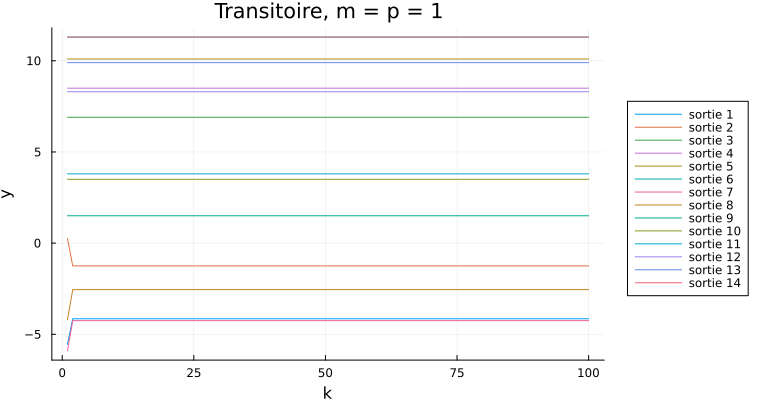

In [13]:
p = plot(title = "Transitoire, m = p = 1", xlabel = "k", ylabel = "y")
for j in 1:min(14, size(y, 2))
    plot!(p, 1:size(y, 1), y[:, j]; label = "sortie $j")
end
display(p)

### Cas avec plus de buffers (m = p = 3)

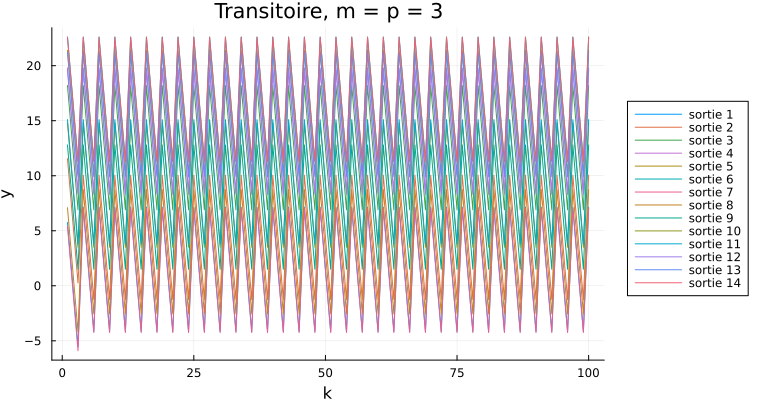

In [14]:
nm3 = fill(3, nmach)
np3 = fill(3, npiece)
_, y3 = flowshop_simu(s, nm3, np3, u)

p2 = plot(title = "Transitoire, m = p = 3", xlabel = "k", ylabel = "y")
for j in 1:min(14, size(y3, 2))
    plot!(p2, 1:size(y3, 1), y3[:, j]; label = "sortie $j")
end
display(p2)

## Récapitulatif des fonctions

| Fonction Julia | Équivalent Scilab | Description |
|----------------|-------------------|-------------|
| `mpshift(n, t)` | `shift(n, t)` | Registre à décalage de n étages |
| `S1 \| S2` | `S1 \| S2` | Composition diagonale (parallèle) |
| `S1 / S2` | `S1 /. S2` | Composition avec rétroaction |
| `explicit(S)` | `explicit(S)` | Conversion forme implicite → explicite |
| `simul(S, u, history)` | `simul(S, u)` | Simulation du système |
| `flowshop(PT)` | `flowshop(PT)` | Construction du système flowshop |
| `flowshop_graph(PT, nm, np)` | `flowshop_graph(PT, nm, np)` | Graphe (T, N) du flowshop |
| `flowshop_simu(s, nm, np, u)` | (script manuel) | Simulation complète encapsulée |
| `semihoward(T, N)` | `semihoward(T, N)` | Algorithme Semi-Howard |